## Frozen Lake  https://gymnasium.farama.org/tutorials/training_agents/frozenlake_q_learning/#sphx-glr-tutorials-training-agents-frozenlake-q-learning-py

Frozen lake involves crossing a frozen lake from start to goal without falling into any holes by walking over the frozen lake. The player may not always move in the intended direction due to the slippery nature of the frozen lake.

In [5]:
from typing import NamedTuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm  # progress bar while code is running, it helps to know whether the code is running or not

import gymnasium as gym
from gymnasium.envs.toy_text.frozen_lake import generate_random_map  # create frozen lake map


sns.set_theme()  # makes plots look nicer

In [7]:
# Parameters
class Params(NamedTuple):
    total_episodes: int  # Total episodes
    learning_rate: float  # Learning rate
    gamma: float  # Discounting rate
    epsilon: float  # Exploration probability
    map_size: int  # Number of tiles of one side of the squared environment
    seed: int  # Define a seed so that we get reproducible results
    is_slippery: bool  # If true the player will move in intended direction with probability of 1/3 else will move in either perpendicular direction with equal probability of 1/3 in both directions
    n_runs: int  # Number of runs
    action_size: int  # Number of possible actions
    state_size: int  # Number of possible states
    proba_frozen: float  # Probability that a tile is frozen

params = Params(              # Setting the hyperparameters 
    total_episodes=2000,  # how many games played
    learning_rate=0.8,  # how fast learning updates
    gamma=0.95,    # importance of future reward
    epsilon=0.1,  # exploration probability; 10% here, 90% exploitation
    map_size=5,  # grid size. 5x5=25 tiles 
    seed=123,   # reproducibility, it will always produce same map. 
    is_slippery=False,  # deterministic movement, easier learning
    n_runs=20,   # repeat experiment multiple times
    action_size=None,
    state_size=None,
    proba_frozen=0.9,   # 90% is frozen, safe. 
)
params

# Set the seed
rng = np.random.default_rng(params.seed)   # rng is a random number generator. seed maintains the reproducibility. 


In [9]:
# The FrozenLake environment.
'''It created the game world. Build a random 5x5 grid where each tile is either Frozen, Hole, start or Goal'''

env = gym.make(   # creates a game environment
    "FrozenLake-v1",   # Game name
    is_slippery=params.is_slippery,     # No slippery, as preset 
    render_mode="rgb_array",   # allows us to take screenshot of the game
    desc=generate_random_map(   # generates a random 5x5 grid where 90% of tiles are safe ice, frozen. 
        size=params.map_size, p=params.proba_frozen, seed=params.seed
    ),
)

In [11]:
# Creating the Q table

params = params._replace(action_size=env.action_space.n)  # Define action and state
params = params._replace(state_size=env.observation_space.n)  #Number of actions (left, right, up, down); Number of states (grid cells)
print(f"Action size: {params.action_size}")
print(f"State size: {params.state_size}")   # state is the tiles. total 25.


class Qlearning:
    def __init__(self, learning_rate, gamma, state_size, action_size):   # it runs automatically and save setting, then reset to start with a blank sheet. 
        self.state_size = state_size
        self.action_size = action_size
        self.learning_rate = learning_rate
        self.gamma = gamma
        self.reset_qtable()

    def update(self, state, action, reward, new_state):   # Bellman equation 
        """Update Q(s,a):= Q(s,a) + lr [R(s,a) + gamma * max Q(s',a') - Q(s,a)]"""
        delta = (
            reward
            + self.gamma * np.max(self.qtable[new_state, :])
            - self.qtable[state, action]
        )
        q_update = self.qtable[state, action] + self.learning_rate * delta
        return q_update

    def reset_qtable(self):
        """Reset the Q-table."""
        self.qtable = np.zeros((self.state_size, self.action_size))


class EpsilonGreedy:  # solves the Exploration vs Exploitation dilemma
    def __init__(self, epsilon):
        self.epsilon = epsilon

    def choose_action(self, action_space, state, qtable):
        """Choose an action `a` in the current world state (s)."""
        # First we randomize a number
        explor_exploit_tradeoff = rng.uniform(0, 1)

        # Exploration
        if explor_exploit_tradeoff < self.epsilon:
            action = action_space.sample()

        # Exploitation (taking the biggest Q-value for this state)
        else:
            # Break ties randomly
            # Find the indices where the Q-value equals the maximum value
            # Choose a random action from the indices where the Q-value is maximum
            max_ids = np.where(qtable[state, :] == max(qtable[state, :]))[0]
            action = rng.choice(max_ids)
        return action

Action size: 4
State size: 25


In [13]:
# RUnning the environment

learner = Qlearning(
    learning_rate=params.learning_rate,
    gamma=params.gamma,
    state_size=params.state_size,
    action_size=params.action_size,
)
explorer = EpsilonGreedy(
    epsilon=params.epsilon,
)

In [15]:
# Training loop

def run_env():
    rewards = np.zeros((params.total_episodes, params.n_runs))
    steps = np.zeros((params.total_episodes, params.n_runs))
    episodes = np.arange(params.total_episodes)
    qtables = np.zeros((params.n_runs, params.state_size, params.action_size))
    all_states = [] # storing the records
    all_actions = []

    for run in range(params.n_runs):  # Outer loop, Repeat 20 times as n_runs=20
        learner.reset_qtable()  # Reset the Q-table between runs. Fresh start each run. 

        for episode in tqdm(        # Middle loop, plays 2000 games per run (episode No)
            episodes, desc=f"Run {run}/{params.n_runs} - Episodes", leave=False
        ):
            state = env.reset(seed=params.seed)[0]  # Reset the environment
            step = 0
            done = False  # game is not over yet
            total_rewards = 0  # No reward collected in this episode

            while not done:  # keeps going untill the game ends. First, pick an action using epsilon-greedy
                action = explorer.choose_action(
                    action_space=env.action_space, state=state, qtable=learner.qtable
                )

                # Record all states and actions
                all_states.append(state)
                all_actions.append(action)

                # Take the action (a) and observe the outcome state(s') and reward (r)
                new_state, reward, terminated, truncated, info = env.step(action)

                done = terminated or truncated  # the game is over; terminated= fell in hole or reached goal; truncated= run too long (hit step limit) 

                learner.qtable[state, action] = learner.update(
                    state, action, reward, new_state
                )

                total_rewards += reward
                step += 1

                # Our new state is state
                state = new_state

            # Log all rewards and steps
            rewards[episode, run] = total_rewards
            steps[episode, run] = step
        qtables[run, :, :] = learner.qtable

    return rewards, steps, episodes, qtables, all_states, all_actions

In [17]:
# Visualization
def postprocess(episodes, params, rewards, steps, map_size):
    """Convert the results of the simulation in dataframes."""
    res = pd.DataFrame(
        data={
            "Episodes": np.tile(episodes, reps=params.n_runs),  # Repeat the episode 20 times
            "Rewards": rewards.flatten(order="F"), # Flatten= Collapses the 2D rewards array into a 1D list
            "Steps": steps.flatten(order="F"),
        }
    )
    res["cum_rewards"] = rewards.cumsum(axis=0).flatten(order="F")  # cumulative sum of rewards
    res["map_size"] = np.repeat(f"{map_size}x{map_size}", res.shape[0])

    st = pd.DataFrame(data={"Episodes": episodes, "Steps": steps.mean(axis=1)})  # average the steps across all 20 runs for each episode. 
    st["map_size"] = np.repeat(f"{map_size}x{map_size}", st.shape[0])
    return res, st


In [19]:
def qtable_directions_map(qtable, map_size):  # This function 
    """Get the best learned action & map it to arrows."""
    qtable_val_max = qtable.max(axis=1).reshape(map_size, map_size)
    qtable_best_action = np.argmax(qtable, axis=1).reshape(map_size, map_size)
    directions = {0: "←", 1: "↓", 2: "→", 3: "↑"}  # action planning by 0,1,2,3 digit
    qtable_directions = np.empty(qtable_best_action.flatten().shape, dtype=str)
    eps = np.finfo(float).eps  # Minimum float number on the machine
    for idx, val in enumerate(qtable_best_action.flatten()):
        if qtable_val_max.flatten()[idx] > eps:
            # Assign an arrow only if a minimal Q-value has been learned as best action
            # otherwise since 0 is a direction, it also gets mapped on the tiles where
            # it didn't actually learn anything
            qtable_directions[idx] = directions[val]
    qtable_directions = qtable_directions.reshape(map_size, map_size)
    return qtable_val_max, qtable_directions

In [21]:
def plot_q_values_map(qtable, env, map_size):
    """Plot the last frame of the simulation and the policy learned."""
    qtable_val_max, qtable_directions = qtable_directions_map(qtable, map_size)

    # Plot the last frame
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
    ax[0].imshow(env.render())
    ax[0].axis("off")
    ax[0].set_title("Last frame")

    # Plot the policy
    sns.heatmap(
        qtable_val_max,
        annot=qtable_directions,
        fmt="",
        ax=ax[1],
        cmap=sns.color_palette("Blues", as_cmap=True),
        linewidths=0.7,
        linecolor="black",
        xticklabels=[],
        yticklabels=[],
        annot_kws={"fontsize": "xx-large"},
    ).set(title="Learned Q-values\nArrows represent best action")
    for _, spine in ax[1].spines.items():
        spine.set_visible(True)
        spine.set_linewidth(0.7)
        spine.set_color("black")
    plt.show()

In [23]:
def plot_states_actions_distribution(states, actions, map_size):
    """Plot the distributions of states and actions."""
    labels = {"LEFT": 0, "DOWN": 1, "RIGHT": 2, "UP": 3}

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
    sns.histplot(data=states, ax=ax[0], kde=True)
    ax[0].set_title("States")
    sns.histplot(data=actions, ax=ax[1])
    ax[1].set_xticks(list(labels.values()), labels=labels.keys())
    ax[1].set_title("Actions")
    fig.tight_layout()
    plt.show()

Map size: 4x4


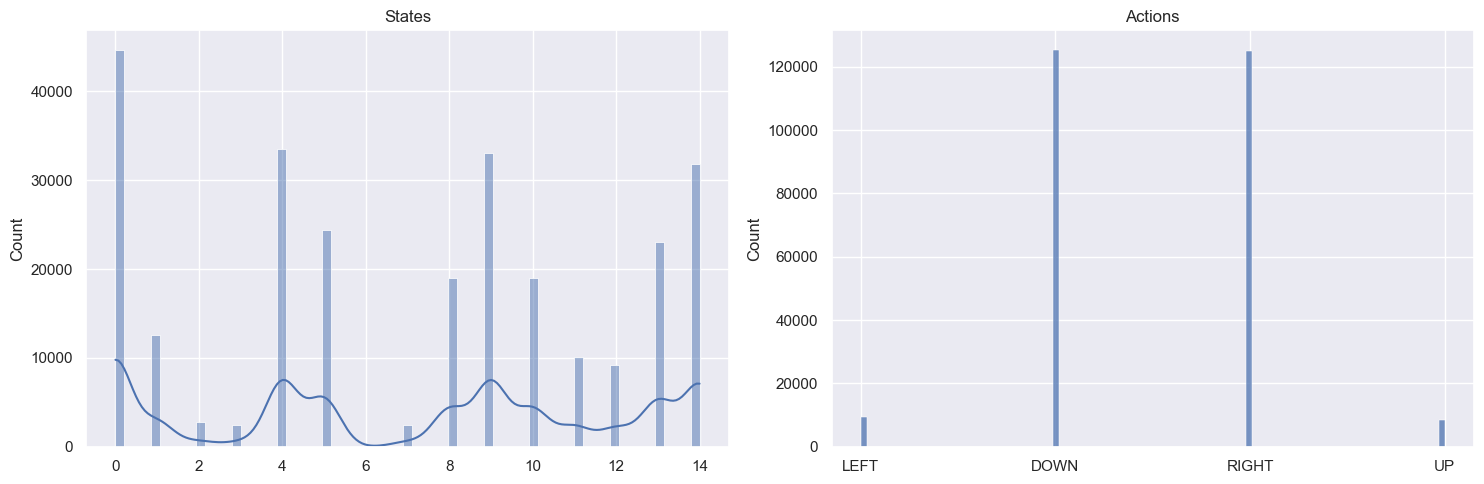

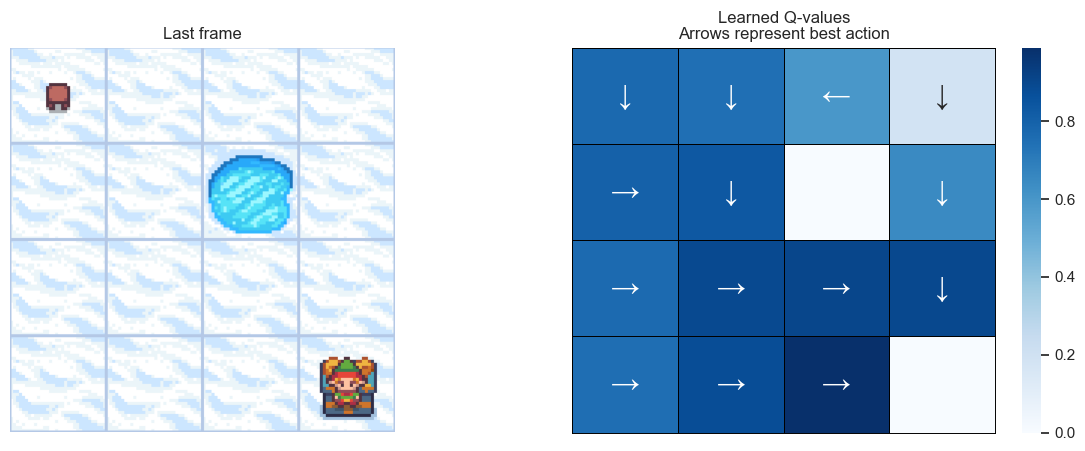

Map size: 7x7


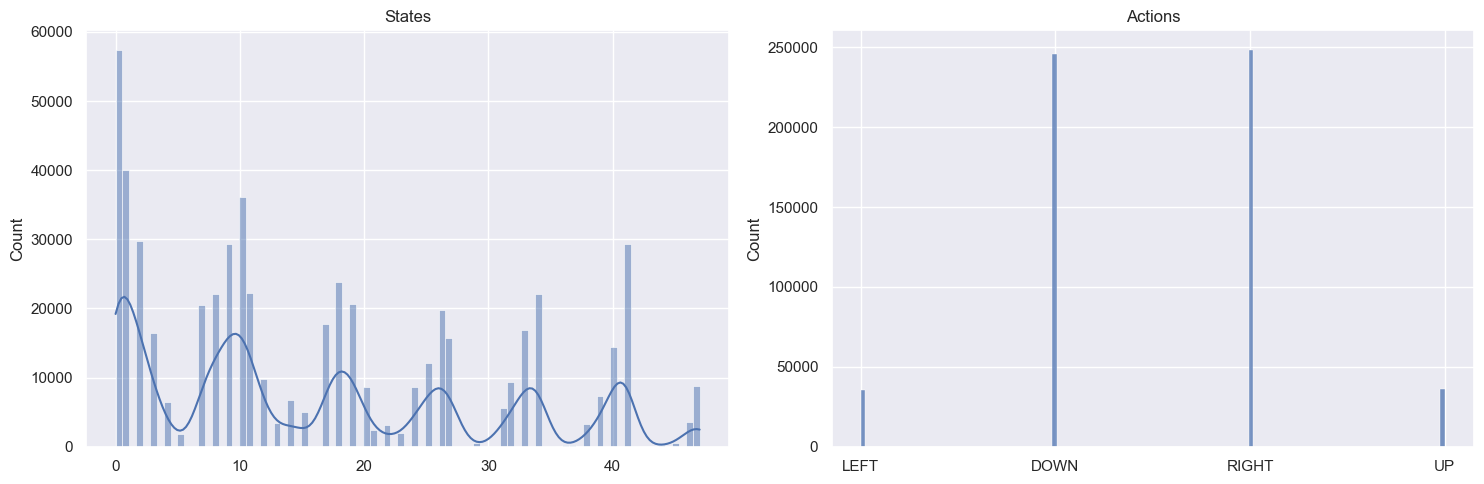

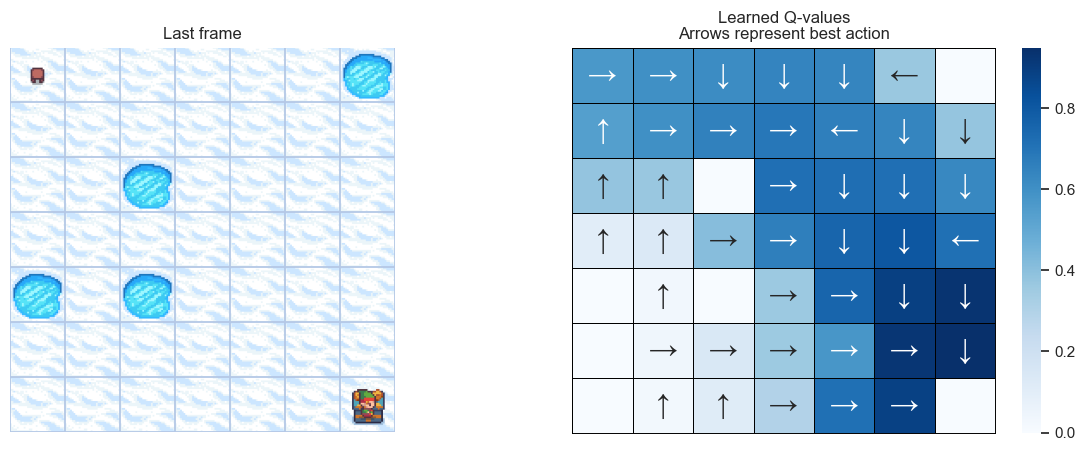

Map size: 9x9


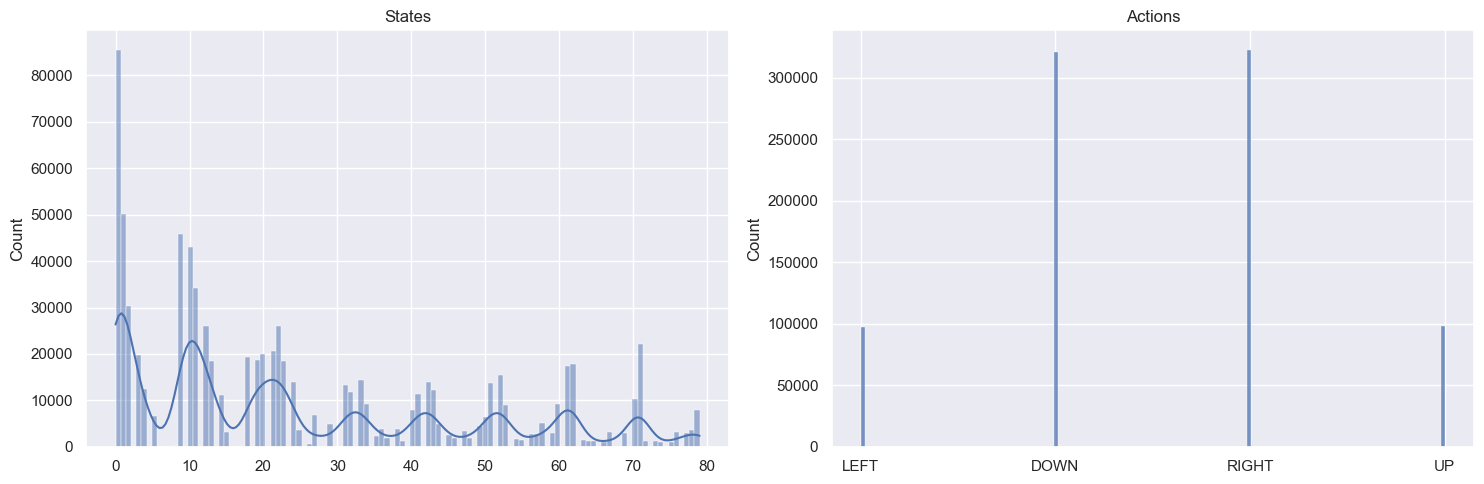

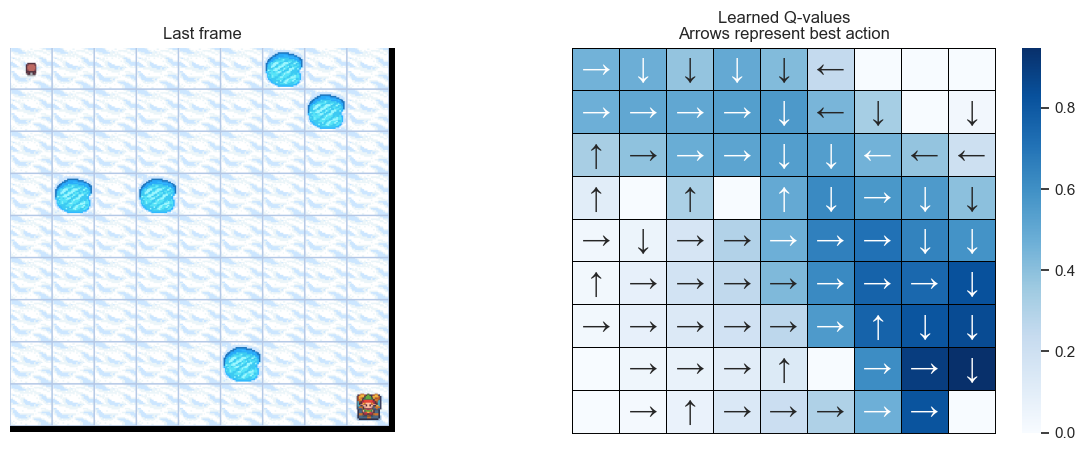

Map size: 11x11


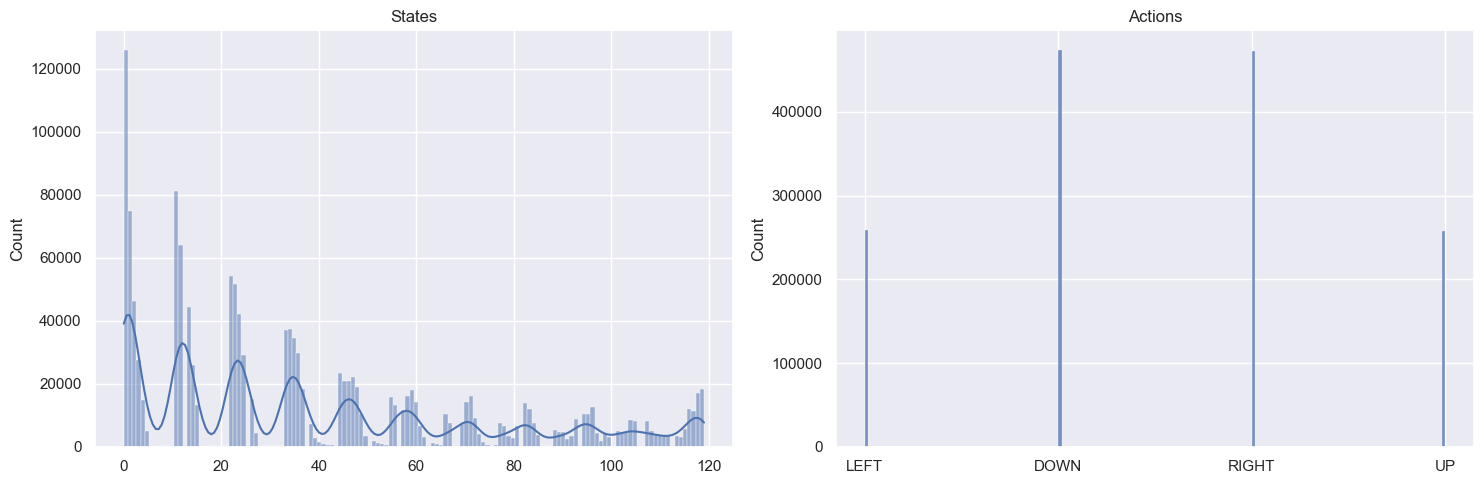

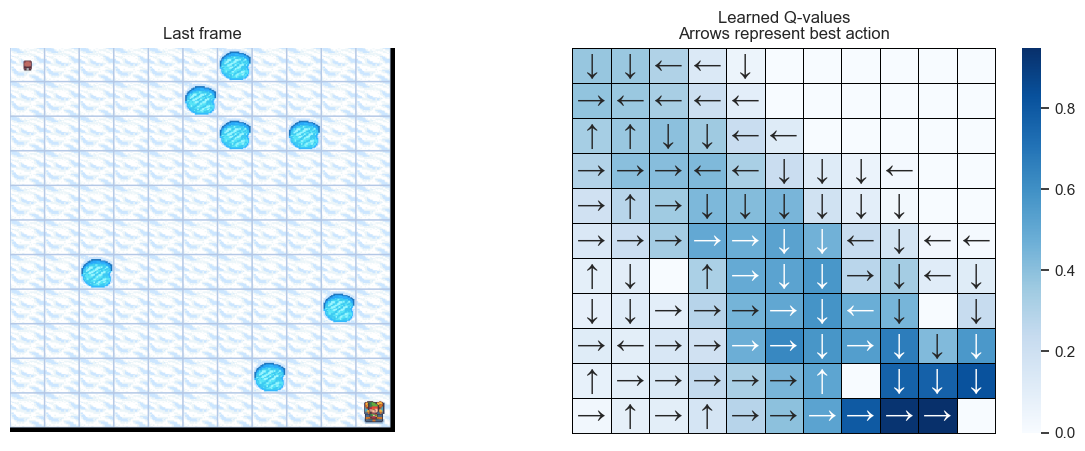

In [27]:
map_sizes = [4, 7, 9, 11]  # Choosing 4 different map_size= tiles to know the performance according to the difficulty level
res_all = pd.DataFrame()
st_all = pd.DataFrame()

for map_size in map_sizes:
    env = gym.make(
        "FrozenLake-v1",
        is_slippery=params.is_slippery,
        render_mode="rgb_array",
        desc=generate_random_map(
            size=map_size, p=params.proba_frozen, seed=params.seed
        ),
    )

    params = params._replace(action_size=env.action_space.n)
    params = params._replace(state_size=env.observation_space.n)
    env.action_space.seed(
        params.seed
    )  # Set the seed to get reproducible results when sampling the action space
    learner = Qlearning(
        learning_rate=params.learning_rate,
        gamma=params.gamma,
        state_size=params.state_size,
        action_size=params.action_size,
    )
    explorer = EpsilonGreedy(
        epsilon=params.epsilon,
    )

    print(f"Map size: {map_size}x{map_size}")
    rewards, steps, episodes, qtables, all_states, all_actions = run_env()

    # Save the results in dataframes
    res, st = postprocess(episodes, params, rewards, steps, map_size)
    res_all = pd.concat([res_all, res])
    st_all = pd.concat([st_all, st])
    qtable = qtables.mean(axis=0)  # Average the Q-table between runs

    plot_states_actions_distribution(
        states=all_states, actions=all_actions, map_size=map_size
    )  # Sanity check
    plot_q_values_map(qtable, env, map_size)

    env.close()

States vs Count graph represent the number of states getting from episodes and n_runs. A 4x4 map has 16 tile (states). Similarly a 9x9 map has 81 tiles. The highest count is on the 0 (starting tile) as expected. The robot aims to go down and left to reach the goal. 

Last Frame: It has been taken from the ending of a particular map. After all 2000 episode with each 20 cycles.
✅ If the robot learned well → the character icon should be ON or near the Goal tile (bottom-right). This means the final game was won!
❌ If the robot didn't learn → the character is somewhere random, possibly in a hole. 
But here the last frame is shown the robot is at the starting tile. The reason is that in every episode the environment is reset. So it shows that the robot is on the starting tile. It does not represent whether it reached the goal or fall in the hole. To know this, we have to look the Q value heatmap. 